In [11]:
# Imports
import numpy as np
from sklearn.model_selection import train_test_split
import math
import matplotlib.pyplot as plt
import time
from model_helpers import gradient_descent, params_to_condensed, predict, accuracy_score, precision_recall, win_prediction_accuracy
rng = np.random.default_rng(seed=69)

In [12]:
# Splitting data into train / cross-validation / test sets
X = np.load("data/duplicate_players_batch_6_2026-06-01 18:30:48.366255.npy")
Y = np.load("data/duplicate_results_batch_6_2026-06-01 18:30:48.366274.npy")
X_train, X_mid, Y_train, Y_mid = train_test_split(X, Y, test_size=0.14, random_state=42)
X_cv, X_test, Y_cv, Y_test = train_test_split(X_mid, Y_mid, test_size=0.5, random_state=42)
print(X_train.shape, X_cv.shape, X_test.shape)
print(Y_train.shape, Y_cv.shape, Y_test.shape)

(1203, 22, 9) (98, 22, 9) (99, 22, 9)
(1203, 121, 1) (98, 121, 1) (99, 121, 1)


In [13]:
# Scale features
mean = np.mean(X_train, axis=(0,1), keepdims=True)
std = np.std(X_train, axis=(0,1), keepdims=True)
std = np.where(std == 0, 1.0, std)

X_train_scaled = (X_train - mean) / std
X_cv_scaled = (X_cv - mean) / std
X_test_scaled = (X_test - mean) / std
print(X_train_scaled.shape)
print(X_cv_scaled.shape)
print(X_test_scaled.shape)

(1203, 22, 9)
(98, 22, 9)
(99, 22, 9)


Cost at epoch 0/1000 = 4.809084929735968
Cost at epoch 1/1000 = 4.808753640380224


Cost at epoch 2/1000 = 4.808422415901517
Cost at epoch 3/1000 = 4.80809125629896
Cost at epoch 4/1000 = 4.80776016157166
Cost at epoch 5/1000 = 4.807429131718725
Cost at epoch 6/1000 = 4.807098166739259
Cost at epoch 7/1000 = 4.806767266632365
Cost at epoch 8/1000 = 4.8064364313971435
Cost at epoch 9/1000 = 4.806105661032691
Cost at epoch 10/1000 = 4.805774955538106
Cost at epoch 11/1000 = 4.8054443149124815
Cost at epoch 12/1000 = 4.805113739154909
Cost at epoch 13/1000 = 4.804783228264478
Cost at epoch 14/1000 = 4.804452782240275
Cost at epoch 15/1000 = 4.804122401081387
Cost at epoch 16/1000 = 4.803792084786895
Cost at epoch 17/1000 = 4.803461835053101
Cost at epoch 18/1000 = 4.803131650455561
Cost at epoch 19/1000 = 4.802801530699647
Cost at epoch 20/1000 = 4.802471475784434
Cost at epoch 21/1000 = 4.802141485708995
Cost at epoch 22/1000 = 4.8018115604724
Cost at epoch 23/1000 = 4.80148170007372
Cost at epoch 24/1000 = 4.801151904512019
Cost at epoch 25/1000 = 4.800822173786362
Cos

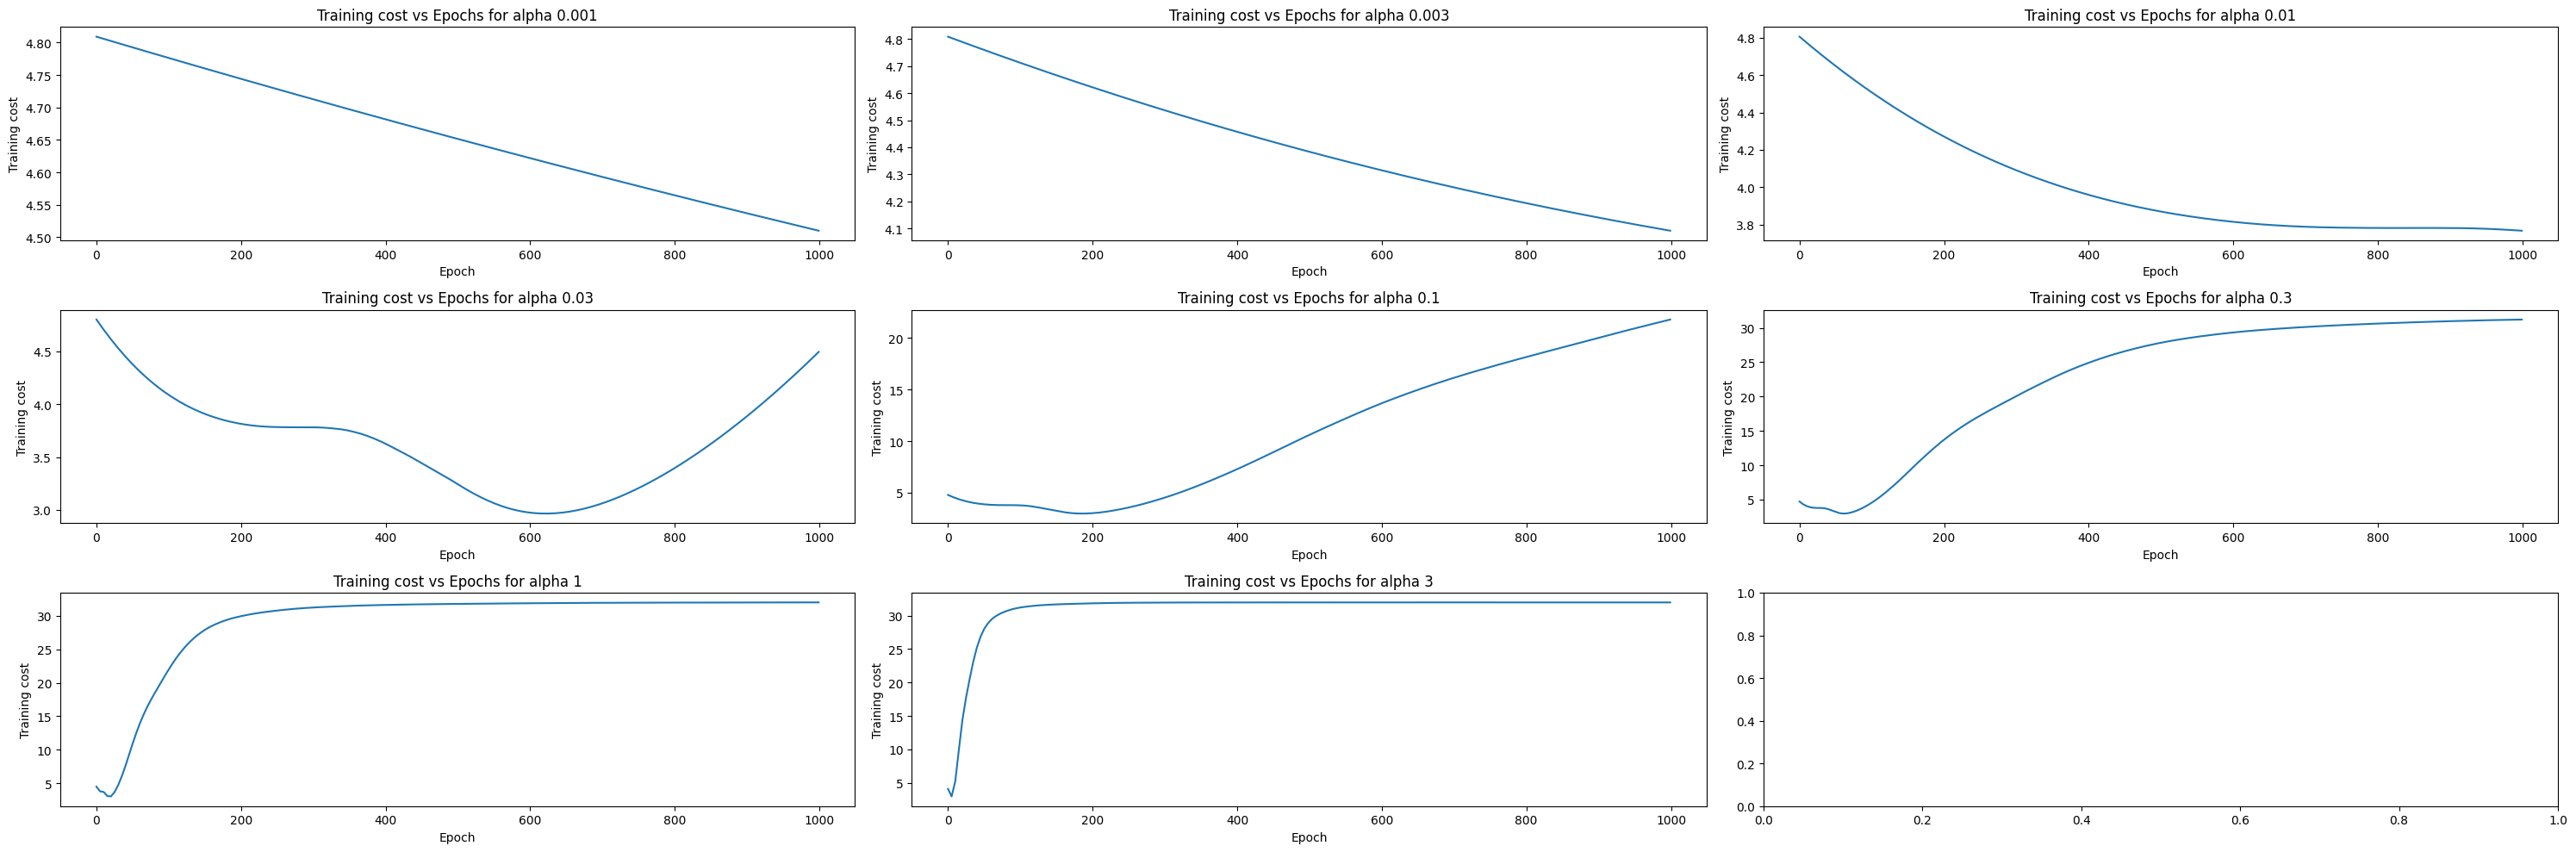

In [14]:
# Look for the best alpha value
# Get initial weights
w_1 = rng.random((1,9)) * np.sqrt(2 / 9)
b_1 = 0
w_2 = rng.random((121, 22)) * np.sqrt(1 / 22)
b_2 = np.zeros((121, 1))

# Alpha values to try
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3]

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(30,10))
start_time = time.perf_counter()
for i in range(len(alphas)):
    # Run gradient descent for each value of alpha with the same initial weights
    # Run gradient descent
    alpha = alphas[i]
    (_, _, _, _, J_train_s) = gradient_descent(
        X=X_train_scaled,
        theta=params_to_condensed(w_p=w_1,b_p=b_1,w_t=w_2,b_t=b_2),
        Y=Y_train,
        alpha=alpha,
        num_iters=1000,
        J_n=5
    )
    
    epochs = [x[0] for x in J_train_s]
    Js = [y[1] for y in J_train_s]
    
    row = math.floor(i / 3)
    column = i % 3
    
    print(f"Js {Js}")
    axs[row][column].plot(epochs, Js)
    axs[row][column].set_xlabel("Epoch")
    axs[row][column].set_ylabel("Training cost")
    axs[row][column].set_title(f"Training cost vs Epochs for alpha {alphas[i]}")

stop_time = time.perf_counter()
execution_time = stop_time - start_time
print(f"Looking for alpha took {execution_time:.6f}s")

plt.tight_layout()
plt.show()

In [15]:
# Can try alpha of 0.01 with around 1000 epochs
alpha = 0.01
epochs = 1000
# Seems that an alpha of 0.3 is the best and it converges at around 1000 epochs. Initialize model with different weights, train with the found hyperparameters above and pick the 
# best model
lowest_J_train = np.inf
new_w_1 = np.array([])
new_w_2 = np.array([])
new_b_1 = np.array([])
new_b_2 = np.array([]),

for attempts in range(5):
    # Get initial weights
    w_1 = rng.random((1,9)) * np.sqrt(2 / 9)
    b_1 = 0
    w_2 = rng.random((121, 22)) * np.sqrt(1 / 22)
    b_2 = np.zeros((121, 1))
    theta = params_to_condensed(w_p=w_1, b_p=b_1, w_t=w_2, b_t=b_2)

    # Run gradient descent
    (temp_new_w_p, temp_new_w_t, temp_new_b_p, temp_new_bt, J_train_s) = gradient_descent(
        X=X_train_scaled,
        theta=theta,
        Y=Y_train,
        alpha=alpha,
        num_iters=epochs
    )
    
    # If cost is lower than lowest found J_train update weights found
    found_J_train = J_train_s[-1][1]
    if found_J_train < lowest_J_train:
        print(f"Lower J_train found {found_J_train}")
        lowest_J_train = found_J_train
        new_w_1 = temp_new_w_p
        new_w_2 = temp_new_w_t
        new_b_1 = temp_new_b_p
        new_b_2 = temp_new_bt 

Cost at epoch 0/1000 = 4.846703902112645
Cost at epoch 1/1000 = 4.843729308375955
Cost at epoch 2/1000 = 4.84076925820061
Cost at epoch 3/1000 = 4.837823463163274
Cost at epoch 4/1000 = 4.83489191408327
Cost at epoch 5/1000 = 4.831974645476638
Cost at epoch 6/1000 = 4.829072457381468
Cost at epoch 7/1000 = 4.826184465962642
Cost at epoch 8/1000 = 4.823311346325309
Cost at epoch 9/1000 = 4.820452235635153
Cost at epoch 10/1000 = 4.817607722470719
Cost at epoch 11/1000 = 4.814777694796693
Cost at epoch 12/1000 = 4.811961640114734
Cost at epoch 13/1000 = 4.809159631672896
Cost at epoch 14/1000 = 4.806371600722587
Cost at epoch 15/1000 = 4.803597494982749
Cost at epoch 16/1000 = 4.800837678345866
Cost at epoch 17/1000 = 4.798092399270531
Cost at epoch 18/1000 = 4.795361583770405
Cost at epoch 19/1000 = 4.7926453556377
Cost at epoch 20/1000 = 4.789943027007282
Cost at epoch 21/1000 = 4.787254744010918
Cost at epoch 22/1000 = 4.784580444638248
Cost at epoch 23/1000 = 4.78192006145909
Cost at

In [16]:
print(f"Lowest training cost found is {lowest_J_train}")

Lowest training cost found is 2.980034186570687


In [17]:
y_pred_cv, _, _ = predict(
    X_cv_scaled,
    theta=params_to_condensed(w_p=new_w_1, b_p=new_b_1, w_t=new_w_2, b_t=new_b_2)
)
accuracy = accuracy_score(y_pred_cv, Y_cv)
print(f"Accuracy of model is {accuracy}")

Accuracy of model is 0.09183673469387756


In [18]:
precision_recall(y_pred=y_pred_cv, y_label=Y_cv)

    Precision and recall
 0-3   TP:0  FP:2  FN:15: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 2  Sample:15
 0-2   TP:0  FP:3  FN:13: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 3  Sample:13
 1-0   TP:0  FP:0  FN:12: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:12
 3-0   TP:9  FP:80  FN:2: Prec:0.1011  Rec:0.8182  F1:22.2222  #Pred: 89  Sample:11
 2-0   TP:0  FP:0  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:10
 0-0   TP:0  FP:0  FN:9: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:9
 0-1   TP:0  FP:4  FN:9: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 4  Sample:9
 0-4   TP:0  FP:0  FN:7: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:7
 0-5   TP:0  FP:0  FN:4: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:4
 4-0   TP:0  FP:0  FN:4: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:4
 5-0   TP:0  FP:0  FN:3: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:3
 0-6   TP:0  FP:0  FN:1: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:1


In [19]:
# Checking if model has high bias, high variance or has reached benchmarks
(train_set_pred, _, _) = predict(
    X=X_train_scaled,
    theta=params_to_condensed(w_p=new_w_1, b_p=new_b_1, w_t=new_w_2, b_t=new_b_2)
)
(cv_set_pred, _, _) = predict(
    X=X_cv_scaled,
    theta=params_to_condensed(w_p=new_w_1, b_p=new_b_1, w_t=new_w_2, b_t=new_b_2)
)

training_set_accuracy = accuracy_score(train_set_pred, Y_train)
cv_set_accuracy = accuracy_score(cv_set_pred, Y_cv)
training_set_win_pred_accuracy = win_prediction_accuracy(y_pred=train_set_pred, y_label=Y_train)
cv_set_win_pred_accuracy = win_prediction_accuracy(y_pred=cv_set_pred, y_label=Y_cv)

print(f"Benchmark Score Accuracy: 0.18")
print(f"Benchmark Win Accuracy  : 0.7542")
print(f"Training Score Accuracy : {training_set_accuracy}")
print(f"Training Win Accuracy   : {training_set_win_pred_accuracy}")
print(f"CV Set Score Accuracy   : {cv_set_accuracy}")
print(f"CV Set Win Accuracy     : {cv_set_win_pred_accuracy}")

Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.11803823773898586
Training Win Accuracy   : 0.4630091438071488
CV Set Score Accuracy   : 0.09183673469387756
CV Set Win Accuracy     : 0.42857142857142855


In [20]:
# Checking if model has high bias, high variance or has reached benchmarks
(train_set_pred, _, _) = predict(
    X=X_train_scaled,
    theta=params_to_condensed(w_p=new_w_1, b_p=new_b_1, w_t=new_w_2, b_t=new_b_2)
)
(test_set_pred, _, _) = predict(
    X=X_test_scaled,
    theta=params_to_condensed(w_p=new_w_1, b_p=new_b_1, w_t=new_w_2, b_t=new_b_2)
)

training_set_accuracy = accuracy_score(train_set_pred, Y_train)
test_set_accuracy = accuracy_score(test_set_pred, Y_test)
training_set_win_pred_accuracy = win_prediction_accuracy(y_pred=train_set_pred, y_label=Y_train)
test_set_win_pred_accuracy = win_prediction_accuracy(y_pred=test_set_pred, y_label=Y_test)

print(f"Benchmark Score Accuracy: 0.18")
print(f"Benchmark Win Accuracy  : 0.7542")
print(f"Training Score Accuracy : {training_set_accuracy}")
print(f"Training Win Accuracy   : {training_set_win_pred_accuracy}")
print(f"Test Set Score Accuracy : {test_set_accuracy}")
print(f"Test Set Win Accuracy   : {test_set_win_pred_accuracy}")

Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.11803823773898586
Training Win Accuracy   : 0.4630091438071488
Test Set Score Accuracy : 0.050505050505050504
Test Set Win Accuracy   : 0.5050505050505051
